**The objective is to identify:**

- Which variables drive the predictions.
- Which variables contribute very little.
- Which features can potentially be removed before hyperparameter tuning.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent      # if notebook is inside notebooks/
DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"

MODEL_DIR.mkdir(exist_ok=True)

### Import the Dataset

In [18]:
X_train = pd.read_csv(DATA_DIR / "processed/base_X_train.csv")
print(X_train.shape)

(40972, 56)


### Import the Required pipelines 

In [19]:
import joblib

rf_pipeline = joblib.load(MODEL_DIR / "baseline_rf_pipe.pkl")
xgb_pipeline = joblib.load(MODEL_DIR / "baseline_xgb_pipe.pkl")
lgbm_pipeline = joblib.load(MODEL_DIR / "baseline_lgbm_pipe.pkl")

models = {
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline,
    "LightGBM": lgbm_pipeline
}

Since Random Forest, XGBoost, and LightGBM all expose feature_importances_, we'll write a reusable function.

In [20]:
def get_feature_importance(pipeline, feature_names):
    """
    Extract feature importance from a trained pipeline.

    Parameters
    ----------
    pipeline : sklearn Pipeline
    feature_names : list-like

    Returns
    -------
    DataFrame
    """

    model = pipeline.named_steps["model"]

    importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model.feature_importances_
    })

    importance = (
        importance
        .sort_values("Importance", ascending=False)
        .reset_index(drop=True)
    )

    return importance

### Extracting Feature Importance

In [21]:
print("Number of features in X_train:", len(X_train.columns))
print("Number of RF importances:", len(rf_pipeline.named_steps["model"].feature_importances_))

print("Number of XGB importances:", len(xgb_pipeline.named_steps["model"].feature_importances_))

print("Number of LGBM importances:", len(lgbm_pipeline.named_steps["model"].feature_importances_))

Number of features in X_train: 56
Number of RF importances: 56
Number of XGB importances: 56
Number of LGBM importances: 56


### This will give the Feature Importance based on different Model Training

In [23]:
rf_importance = get_feature_importance(rf_pipeline, X_train.columns)
xgb_importance = get_feature_importance(xgb_pipeline, X_train.columns)
lgbm_importance = get_feature_importance(lgbm_pipeline, X_train.columns)

### Preview Top Features

In [24]:
display(rf_importance.head(10))
display(xgb_importance.head(10))
display(lgbm_importance.head(10))

,Feature,Importance
0,Age_Oldest_TL,0.120926
1,enq_L3m,0.096613
2,time_since_recent_enq,0.076643
3,num_std_12mts,0.059721
4,time_since_recent_payment,0.041548
5,Time_With_Curr_Empr,0.040835
6,Age_Newest_TL,0.036675
7,pct_PL_enq_L6m_of_ever,0.036083
8,NETMONTHLYINCOME,0.035976
9,pct_currentBal_all_TL,0.035472


,Feature,Importance
0,enq_L3m,0.213921
1,Age_Oldest_TL,0.089177
2,num_std_12mts,0.079915
3,max_recent_level_of_deliq,0.074651
4,pct_PL_enq_L6m_of_ever,0.055361
5,max_deliq_12mts,0.032842
6,max_deliq_6mts,0.027205
7,recent_level_of_deliq,0.027104
8,time_since_recent_enq,0.026709
9,Age_Newest_TL,0.021375


,Feature,Importance
0,Age_Oldest_TL,2664
1,time_since_recent_enq,1818
2,Time_With_Curr_Empr,1538
3,time_since_recent_payment,1513
4,num_std_12mts,1353
5,NETMONTHLYINCOME,1285
6,Age_Newest_TL,1164
7,pct_currentBal_all_TL,1163
8,enq_L3m,1137
9,max_recent_level_of_deliq,1113


In [25]:
import matplotlib.pyplot as plt

def plot_feature_importance(importance_df, model_name, top_n=20):
    """
    Plot the top N most important features.
    """

    top_features = importance_df.head(top_n)

    plt.figure(figsize=(10, 8))
    plt.barh(top_features["Feature"][::-1],
             top_features["Importance"][::-1])

    plt.title(f"Top {top_n} Feature Importance - {model_name}")
    plt.xlabel("Importance Score")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.show()

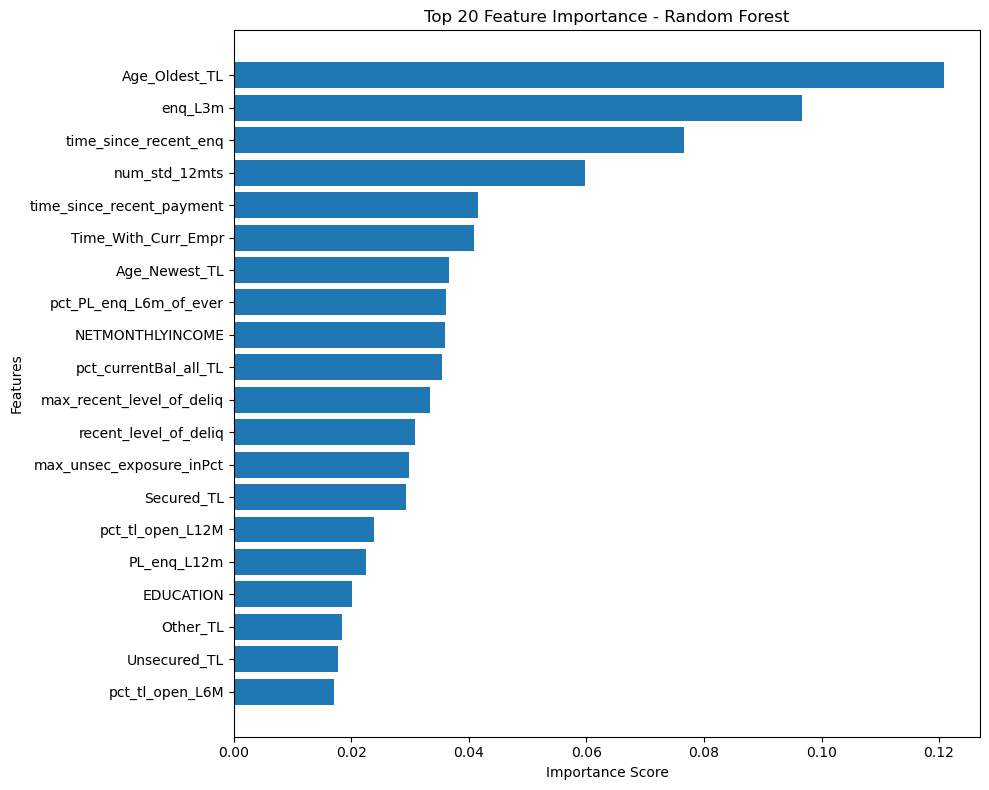

In [26]:
plot_feature_importance(rf_importance, "Random Forest")

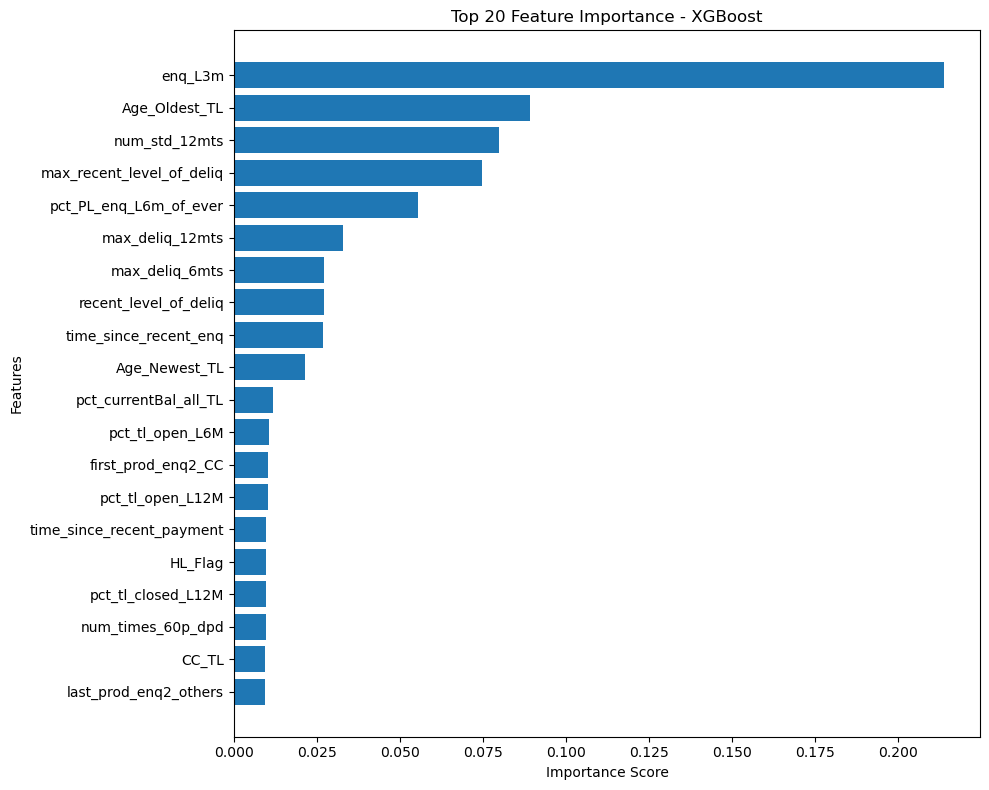

In [27]:
plot_feature_importance(xgb_importance, "XGBoost")

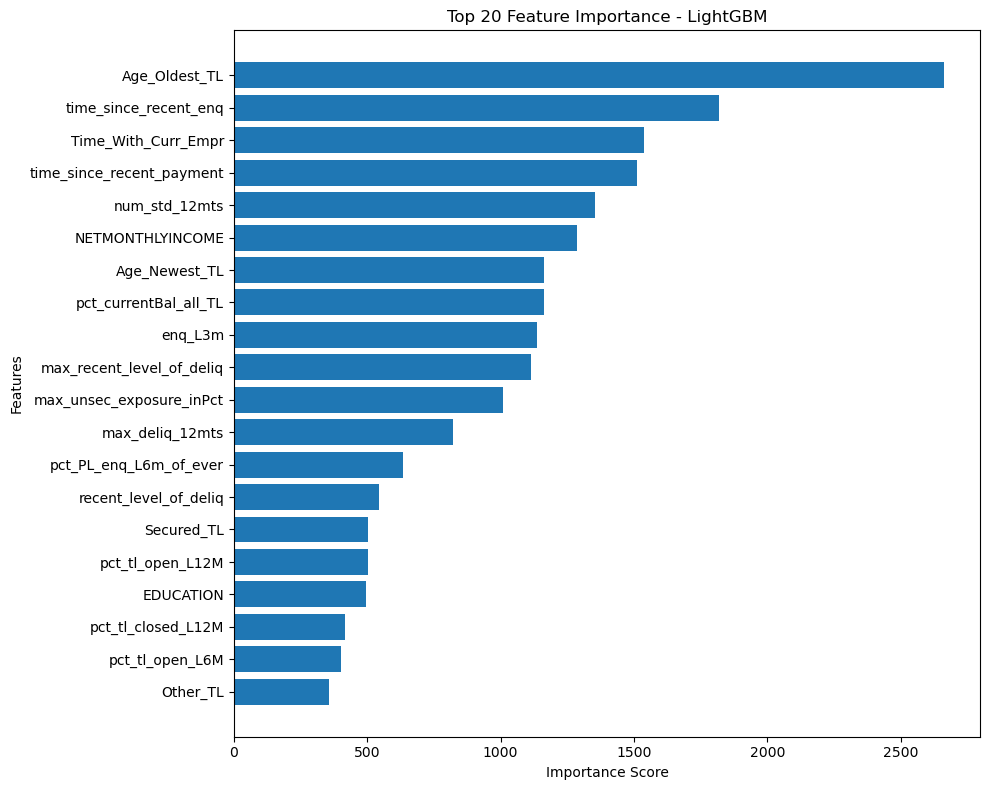

In [28]:
plot_feature_importance(lgbm_importance, "LightGBM")

In [29]:
feature_importance_comparison = (
    rf_importance.rename(columns={"Importance": "RF_Importance"})
    .merge(
        xgb_importance.rename(columns={"Importance": "XGB_Importance"}),
        on="Feature"
    )
    .merge(
        lgbm_importance.rename(columns={"Importance": "LGBM_Importance"}),
        on="Feature"
    )
)

feature_importance_comparison.head()

,Feature,RF_Importance,XGB_Importance,LGBM_Importance
0,Age_Oldest_TL,0.120926,0.089177,2664
1,enq_L3m,0.096613,0.213921,1137
2,time_since_recent_enq,0.076643,0.026709,1818
3,num_std_12mts,0.059721,0.079915,1353
4,time_since_recent_payment,0.041548,0.009738,1513


### Computing Average Importance Of Top 20 Features

In [31]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

comparison = feature_importance_comparison.copy()

comparison["RF_norm"] = scaler.fit_transform(
    comparison[["RF_Importance"]]
)

comparison["XGB_norm"] = scaler.fit_transform(
    comparison[["XGB_Importance"]]
)

comparison["LGBM_norm"] = scaler.fit_transform(
    comparison[["LGBM_Importance"]]
)

comparison["Average_Importance"] = comparison[
    ["RF_norm", "XGB_norm", "LGBM_norm"]
].mean(axis=1)

comparison = comparison.sort_values(
    "Average_Importance",
    ascending=False
)

comparison.head(20)

,Feature,RF_Importance,XGB_Importance,LGBM_Importance,Average_Importance,RF_norm,XGB_norm,LGBM_norm
0,Age_Oldest_TL,0.120926,0.089177,2664,0.805623,1.000000,0.416870,1.000000
8,enq_L3m,0.096613,0.213921,1137,0.741872,0.798813,1.000000,0.426802
1,time_since_recent_enq,0.076643,0.026709,1818,0.480282,0.633559,0.124854,0.682432
4,num_std_12mts,0.059721,0.079915,1353,0.458328,0.493526,0.373574,0.507883
9,max_recent_level_of_deliq,0.033329,0.074651,1113,0.347297,0.275132,0.348966,0.417793
3,time_since_recent_payment,0.041548,0.009738,1513,0.318869,0.343144,0.045521,0.567943
2,Time_With_Curr_Empr,0.040835,0.008426,1538,0.317986,0.337240,0.039390,0.577327
6,Age_Newest_TL,0.036675,0.021375,1164,0.279892,0.302820,0.099920,0.436937
5,NETMONTHLYINCOME,0.035976,0.008358,1285,0.272821,0.297037,0.039070,0.482357
12,pct_PL_enq_L6m_of_ever,0.036083,0.055361,633,0.264774,0.297918,0.258792,0.237613


We will now move forward to Hyperparameter tuning of XGBoost and LightGBM (using RandomizedSearchCV or Optuna), followed by SHAP analysis of the best-performing model.